# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

In [8]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Исходные данные
p1 = 0.35 # Первая выборка
p2 = 0.40 # Вторая выборка
alpha = 0.05 # p-value
power = 0.8  # Мощность (1 - beta)
beta = 1 - power # Ошибка 2 рода

# Расчет объединенной пропорции
p_bar = (p1 + p2) / 2

# Квантили нормального распределения
z_1_alpha_2 = norm.ppf(1 - alpha / 2)
z_1_beta = norm.ppf(1 - beta)

# 1. Расчет минимального размера выборки
n_numerator = (z_1_alpha_2 * np.sqrt(2 * p_bar * (1 - p_bar)) + \
               z_1_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2
n_denominator = (p1 - p2)**2

n = n_numerator / n_denominator

# Округляем n
n_rounded = np.ceil(n)

print(f"Вероятность в группе 1 p1: {p1}")
print(f"Вероятность в группе 2 p2: {p2}")
print(f"Мощность теста: {power}")
print(f"p-value: {alpha}")
print('1. Определение минимального размера выборки:')
print(f"n1 = n2 = {int(n_rounded)}")




Вероятность в группе 1 p1: 0.35
Вероятность в группе 2 p2: 0.4
Мощность теста: 0.8
p-value: 0.05
1. Определение минимального размера выборки:
n1 = n2 = 1471


In [ ]:
# 2. Преобразование распределений через ЦПТ

# Используем рассчитанный минимальный размер выборки n для равных выборок
n_equal = int(n_rounded)

# Параметры нормального распределения для первой выборки
mu1_equal = p1
sigma1_equal = np.sqrt((p1 * (1 - p1)) / n_equal)
mu2_equal = p2
sigma2_equal = np.sqrt((p2 * (1 - p2)) / n_equal)

print(f"2. Преобразование распределений через ЦПТ:")
print(f'Равные выборки (n={int(n_equal)}):')
print(f" Группа 1: N(μ={mu1_equal:.4f}, σ={sigma1_equal:.4f})")
print(f" Группа 2: N(μ={mu2_equal:.4f}, σ={sigma2_equal:.4f})")

# Расчет для неравных выборок
n_unequal1 = 735
n_unequal2 = 7350 

# Параметры норм распределения
mu1_unequal = p1
sigma1_unequal = np.sqrt((p1 * (1 - p1)) / n_unequal1)
mu2_unequal = p2
sigma2_unequal = np.sqrt((p2 * (1 - p2)) / n_unequal2)

print(f'Неравные выборки (n1={int(n_unequal1)}, n2={int(n_unequal2)}):')
print(f" Группа 1: N(μ={mu1_unequal:.4f}, σ={sigma1_unequal:.4f})")
print(f" Группа 2: N(μ={mu2_unequal:.4f}, σ={sigma2_unequal:.4f})")


2. Преобразование распределений через ЦПТ:
Равные выборки (n=1471):
 Группа 1: N(μ=0.3500, σ=0.0124)
 Группа 2: N(μ=0.4000, σ=0.0128)
Неравные выборки (n1=735, n2=7350):
 Группа 1: N(μ=0.3500, σ=0.0176)
 Группа 2: N(μ=0.4000, σ=0.0057)


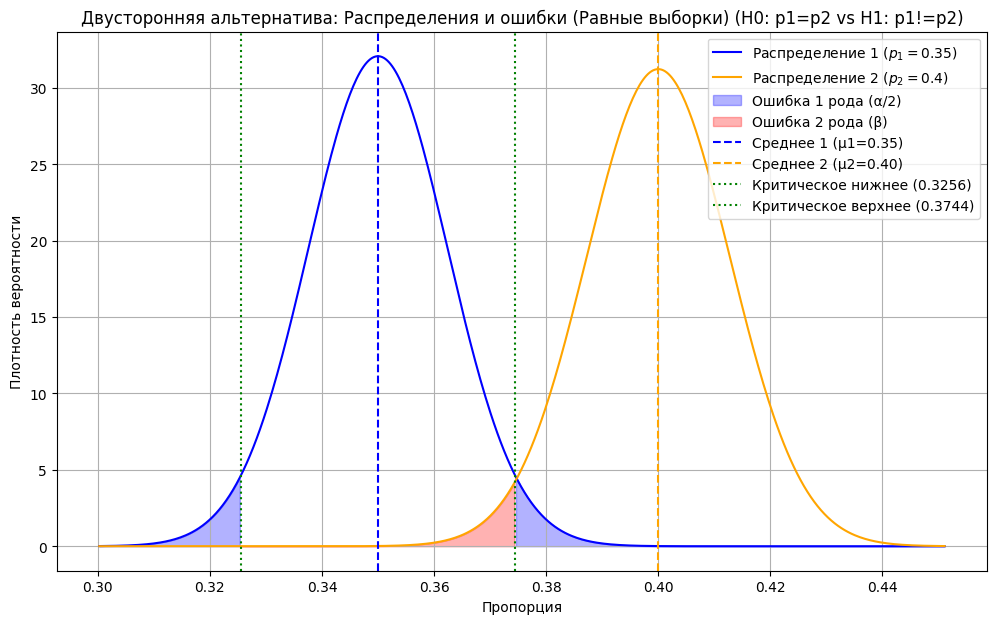

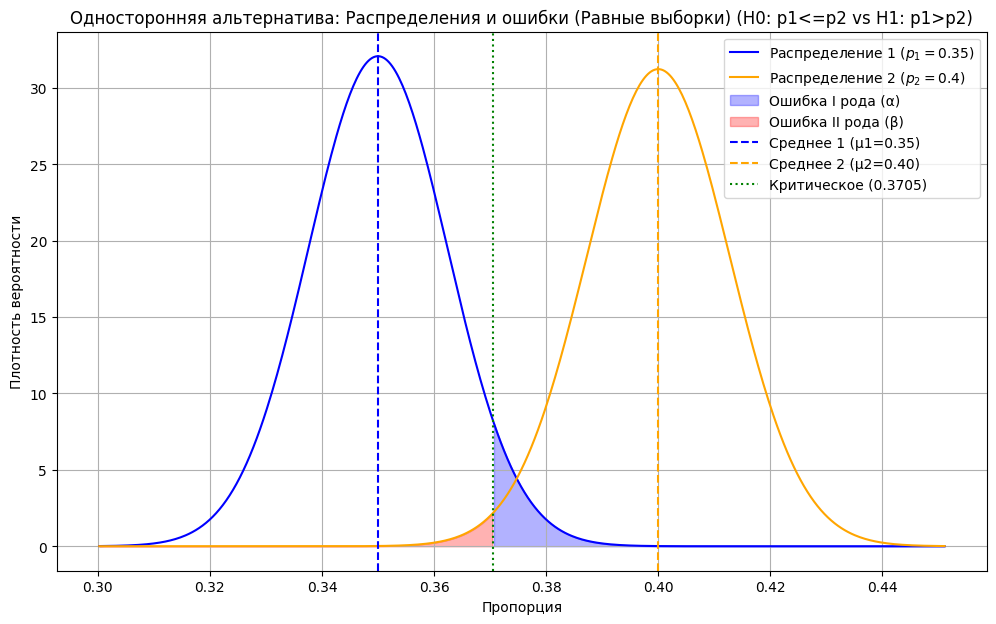

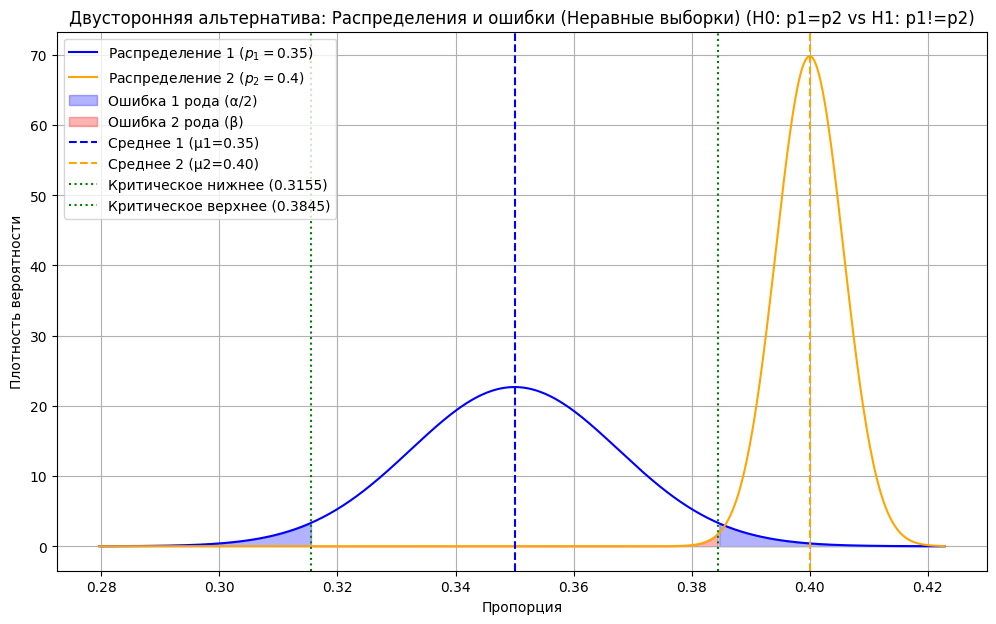

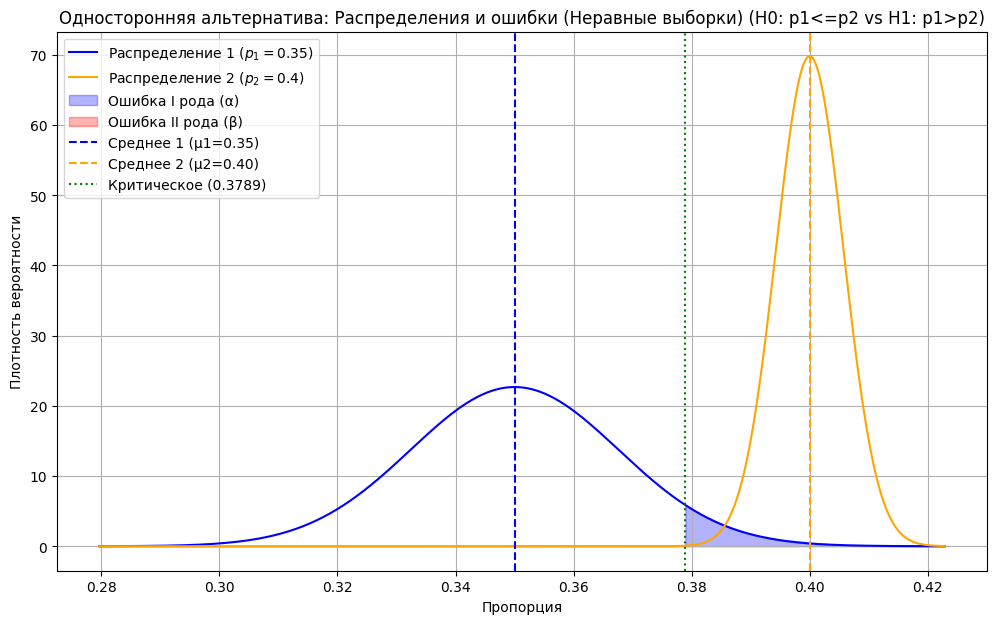

In [11]:
# 3. Визуализация распределений и ошибок

def plot_distributions_and_errors(mu1, sigma1, mu2, sigma2, p1, p2, alpha, title_suffix):
    # Определяем диапазон значений для оси X
    x = np.linspace(min(mu1 - 4 * sigma1, mu2 - 4 * sigma2),
                    max(mu1 + 4 * sigma1, mu2 + 4 * sigma2), 500)

    # PDF для двух распределений
    pdf1 = norm.pdf(x, mu1, sigma1)
    pdf2 = norm.pdf(x, mu2, sigma2)

    # График 1: Двусторонняя альтернатива 
    plt.figure(figsize=(12, 7))
    plt.plot(x, pdf1, label=f'Распределение 1 ($p_1={p1}$)', color='blue')
    plt.plot(x, pdf2, label=f'Распределение 2 ($p_2={p2}$)', color='orange')

    # Критические значения для двустороннего теста (относительно N(mu1, sigma1))
    z_alpha_half = norm.ppf(1 - alpha / 2)
    critical_lower_two_sided = mu1 - z_alpha_half * sigma1
    critical_upper_two_sided = mu1 + z_alpha_half * sigma1

    # Область ошибки 1 рода (альфа) - синий
    x_alpha_left = x[x < critical_lower_two_sided]
    y_alpha_left = norm.pdf(x_alpha_left, mu1, sigma1)
    plt.fill_between(x_alpha_left, y_alpha_left, color='blue', alpha=0.3, label='Ошибка 1 рода (α/2)')

    x_alpha_right = x[x > critical_upper_two_sided]
    y_alpha_right = norm.pdf(x_alpha_right, mu1, sigma1)
    plt.fill_between(x_alpha_right, y_alpha_right, color='blue', alpha=0.3)

    # Область ошибки 2 рода (бета) - красная
    x_beta_two_sided = x[(x >= critical_lower_two_sided) & (x <= critical_upper_two_sided)]
    y_beta_two_sided = norm.pdf(x_beta_two_sided, mu2, sigma2)
    plt.fill_between(x_beta_two_sided, y_beta_two_sided, color='red', alpha=0.3, label='Ошибка 2 рода (β)')

    # Вертикальные линии
    plt.axvline(mu1, color='blue', linestyle='--', label=f'Среднее 1 (μ1={mu1:.2f})')
    plt.axvline(mu2, color='orange', linestyle='--', label=f'Среднее 2 (μ2={mu2:.2f})')
    plt.axvline(critical_lower_two_sided, color='green', linestyle=':', label=f'Критическое нижнее ({critical_lower_two_sided:.4f})')
    plt.axvline(critical_upper_two_sided, color='green', linestyle=':', label=f'Критическое верхнее ({critical_upper_two_sided:.4f})')

    plt.title(f'Двусторонняя альтернатива: Распределения и ошибки {title_suffix} (H0: p1=p2 vs H1: p1!=p2)')
    plt.xlabel('Пропорция')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True)
    plt.show()

    # График 2: Односторонняя альтернатива (p1 > p2) 
    plt.figure(figsize=(12, 7))
    plt.plot(x, pdf1, label=f'Распределение 1 ($p_1={p1}$)', color='blue')
    plt.plot(x, pdf2, label=f'Распределение 2 ($p_2={p2}$)', color='orange')

    # Критическое значение для одностороннего теста (относительно N(mu1, sigma1))
    z_alpha_one_sided = norm.ppf(1 - alpha) 
    critical_one_sided = mu1 + z_alpha_one_sided * sigma1

    # Область ошибки 1 рода (альфа) 
    x_alpha_one_sided = x[x > critical_one_sided]
    y_alpha_one_sided = norm.pdf(x_alpha_one_sided, mu1, sigma1)
    plt.fill_between(x_alpha_one_sided, y_alpha_one_sided, color='blue', alpha=0.3, label='Ошибка I рода (α)')

    # Область ошибки 2 рода (бета) 
    x_beta_one_sided = x[x < critical_one_sided]
    y_beta_one_sided = norm.pdf(x_beta_one_sided, mu2, sigma2)
    plt.fill_between(x_beta_one_sided, y_beta_one_sided, color='red', alpha=0.3, label='Ошибка II рода (β)')

    # Вертикальные линии
    plt.axvline(mu1, color='blue', linestyle='--', label=f'Среднее 1 (μ1={mu1:.2f})')
    plt.axvline(mu2, color='orange', linestyle='--', label=f'Среднее 2 (μ2={mu2:.2f})')
    plt.axvline(critical_one_sided, color='green', linestyle=':', label=f'Критическое ({critical_one_sided:.4f})')

    plt.title(f'Односторонняя альтернатива: Распределения и ошибки {title_suffix} (H0: p1<=p2 vs H1: p1>p2)')
    plt.xlabel('Пропорция')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True)
    plt.show()



plot_distributions_and_errors(mu1_equal, sigma1_equal, mu2_equal, sigma2_equal, p1, p2, alpha, '(Равные выборки)')


plot_distributions_and_errors(mu1_unequal, sigma1_unequal, mu2_unequal, sigma2_unequal, p1, p2, alpha, '(Неравные выборки)')

In [ ]:
# 4. Расчет доверительных интервалов

# Квантиль нормального распределения для 95% доверительного интервала
z_confidence = norm.ppf(1 - alpha / 2)

print("4. Расчет доверительных интервалов:")

# Для равных выборок
# Доверительный интервал для первой выборки (p1)
ci_lower1_equal = p1 - z_confidence * np.sqrt((p1 * (1 - p1)) / n_equal)
ci_upper1_equal = p1 + z_confidence * np.sqrt((p1 * (1 - p1)) / n_equal)
width1_equal = ci_upper1_equal - ci_lower1_equal

# Доверительный интервал для второй выборки (p2)
ci_lower2_equal = p2 - z_confidence * np.sqrt((p2 * (1 - p2)) / n_equal)
ci_upper2_equal = p2 + z_confidence * np.sqrt((p2 * (1 - p2)) / n_equal)
width2_equal = ci_upper2_equal - ci_lower2_equal

print(f"Равные выборки (n={n_equal}):")
print(f" Группа 1: [{ci_lower1_equal:.4f}, {ci_upper1_equal:.4f}], Ширина: {width1_equal:.4f}")
print(f" Группа 2: [{ci_lower2_equal:.4f}, {ci_upper2_equal:.4f}], Ширина: {width2_equal:.4f}")

# Для неравных выборок
# Доверительный интервал для первой выборки (p1) 
ci_lower1_unequal = p1 - z_confidence * np.sqrt((p1 * (1 - p1)) / n_unequal1)
ci_upper1_unequal = p1 + z_confidence * np.sqrt((p1 * (1 - p1)) / n_unequal1)
width1_unequal = ci_upper1_unequal - ci_lower1_unequal

# Доверительный интервал для второй выборки (p2) 
ci_lower2_unequal = p2 - z_confidence * np.sqrt((p2 * (1 - p2)) / n_unequal2)
ci_upper2_unequal = p2 + z_confidence * np.sqrt((p2 * (1 - p2)) / n_unequal2)
width2_unequal = ci_upper2_unequal - ci_lower2_unequal

print(f"Неравные выборки (n1={n_unequal1}, n2={n_unequal2}):")
print(f" Группа 1: [{ci_lower1_unequal:.4f}, {ci_upper1_unequal:.4f}], Ширина: {width1_unequal:.4f}")
print(f" Группа 2: [{ci_lower2_unequal:.4f}, {ci_upper2_unequal:.4f}], Ширина: {width2_unequal:.4f}")


4. Расчет доверительных интервалов:
Равные выборки (n=1471):
 Группа 1: [0.3256, 0.3744], Ширина: 0.0487
 Группа 2: [0.3750, 0.4250], Ширина: 0.0501
Неравные выборки (n1=735, n2=7350):
 Группа 1: [0.3155, 0.3845], Ширина: 0.0690
 Группа 2: [0.3888, 0.4112], Ширина: 0.0224


Расчёт демонстрирует ключевую закономерность: ширина доверительного интервала обратно пропорциональна размеру выборки.

Случай равных выборок (n=1471):

ДИ для Группы 1 (p₁=0,35): ширина ≈ 0,0487

ДИ для Группы 2 (p₂=0,40): ширина ≈ 0,0501

При одинаковом объёме выборок ширина доверительных интервалов практически совпадает.

Случай неравных выборок:

Меньшая выборка (n₁=735): ширина ДИ увеличилась до 0,0690.

Большая выборка (n₂=7350): ширина ДИ сузилась до 0,0224.

Это наглядно подтверждает, что с уменьшением объёма данных оценка становится менее точной (интервал расширяется), а с увеличением выборки — более точной (интервал сужается).